In [2]:
import sys
sys.path.append('..')

import torch
import json
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from src.utils import get_device, get_quantum_device, set_seed
from src.dataset import get_dataloaders
from src.models import HybridModel
from src.train import train

set_seed(42)
device = get_quantum_device()
print(f"Device: {device}")

Seed set: 42
Device: cpu


In [3]:
model = HybridModel()
print(model)

dummy = torch.randn(2, 3, 64, 64)
out = model(dummy)
print(f"Output shape: {out.shape}")

HybridModel(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_featu

In [4]:
train_loader, val_loader, test_loader = get_dataloaders(batch_size=32, augment=True)
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 591
Val batches:   127
Test batches:  127


In [5]:
from torch.utils.data import Subset, DataLoader

small_train = Subset(train_loader.dataset, range(64))
small_val   = Subset(val_loader.dataset, range(32))

small_train_loader = DataLoader(small_train, batch_size=8, shuffle=True)
small_val_loader   = DataLoader(small_val, batch_size=8, shuffle=False)

In [6]:
import time

start = time.time()
history = train(model, small_train_loader, small_val_loader,
                epochs=1, lr=0.0005, device=device, save_name='hybrid_vqc_smoketest')
print(f"\nTime for 1 epoch on 64 samples: {time.time() - start:.1f}s")

Epoch 1/1 | Loss: 2.3688 | Val Acc: 0.0000

Time for 1 epoch on 64 samples: 2.8s


In [7]:
import numpy as np
from torchvision import datasets
from torch.utils.data import Subset, DataLoader, random_split
from src.dataset import get_transforms, DATA_DIR

# Load full EuroSAT dataset with training transforms
full_dataset = datasets.EuroSAT(root=DATA_DIR, download=True, transform=get_transforms(augment=True))

# Balanced sampling — 200 images per class
targets = np.array(full_dataset.targets)
samples_per_class = 200

balanced_indices = []
for class_idx in range(10):
    class_indices = np.where(targets == class_idx)[0]
    chosen = np.random.choice(class_indices, samples_per_class, replace=False)
    balanced_indices.extend(chosen)

np.random.shuffle(balanced_indices)
balanced_subset = Subset(full_dataset, balanced_indices)

# 80/20 train/val split
n = len(balanced_subset)
train_n = int(0.8 * n)
val_n = n - train_n
train_subset, val_subset = random_split(balanced_subset, [train_n, val_n])

vqc_train_loader = DataLoader(train_subset, batch_size=8, shuffle=True)
vqc_val_loader   = DataLoader(val_subset, batch_size=8, shuffle=False)

print(f"Total: {n} | Train: {len(train_subset)} | Val: {len(val_subset)}")

Total: 2000 | Train: 1600 | Val: 400


In [8]:
import time

model = HybridModel()
start = time.time()
history = train(model, vqc_train_loader, vqc_val_loader,
                epochs=5, lr=0.0005, device=device, save_name='hybrid_vqc_quick')
print(f"\nTotal time: {(time.time()-start)/60:.1f} min")

Epoch 1/5 | Loss: 2.2807 | Val Acc: 0.0950
  ✓ Checkpoint saved (0.0950)
Epoch 2/5 | Loss: 2.2427 | Val Acc: 0.1400
  ✓ Checkpoint saved (0.1400)
Epoch 3/5 | Loss: 2.2106 | Val Acc: 0.1550
  ✓ Checkpoint saved (0.1550)
Epoch 4/5 | Loss: 2.1865 | Val Acc: 0.2700
  ✓ Checkpoint saved (0.2700)
Epoch 5/5 | Loss: 2.1540 | Val Acc: 0.3300
  ✓ Checkpoint saved (0.3300)

Total time: 11.9 min


In [9]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in vqc_val_loader:
        preds = model(images).argmax(dim=1)
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

import collections
print("Predicted class distribution:", collections.Counter(all_preds))
print("True class distribution:    ", collections.Counter(all_labels))

Predicted class distribution: Counter({9: 162, 0: 104, 4: 68, 8: 38, 3: 14, 7: 7, 6: 7})
True class distribution:     Counter({2: 46, 4: 46, 8: 44, 3: 42, 9: 41, 1: 39, 6: 39, 0: 38, 5: 36, 7: 29})


In [10]:
model.eval()
with torch.no_grad():
    # Grab a small batch of real images
    images, labels = next(iter(vqc_val_loader))

    # Step through the pipeline manually
    x = model.features(images)
    x = x.view(x.size(0), -1)
    x = torch.relu(model.fc(x))          # before dropout, 256-dim features

    pre_out = model.vqc.pre(x)           # input to quantum circuit, 4-dim
    print("Pre-quantum (input to circuit) — first 5 samples:")
    print(pre_out[:5])

    q_out = torch.stack([model.vqc.qlayer(pre_out[i]) for i in range(pre_out.shape[0])])
    print("\nQuantum circuit output — first 5 samples:")
    print(q_out[:5])

Pre-quantum (input to circuit) — first 5 samples:
tensor([[-0.3021,  0.9661, -0.2844,  0.9432],
        [-0.3114,  0.9882, -0.3084,  0.9786],
        [-0.2924,  0.8198, -0.2635,  0.6997],
        [-0.2513,  0.9868, -0.2668,  0.9780],
        [-0.3414,  0.9664, -0.2641,  0.9458]])

Quantum circuit output — first 5 samples:
tensor([[0.0857, 0.0184, 0.1524, 0.7537],
        [0.0806, 0.0182, 0.1433, 0.7567],
        [0.1314, 0.0151, 0.2332, 0.6785],
        [0.0787, 0.0187, 0.1320, 0.7790],
        [0.0824, 0.0182, 0.1560, 0.7486]])


In [11]:
model.eval()
with torch.no_grad():
    images, labels = next(iter(vqc_val_loader))

    x = model.features(images)
    x = x.view(x.size(0), -1)
    x = torch.relu(model.fc(x))

    pre_out = model.vqc.pre(x)
    print("Pre-quantum (input to circuit) — first 5 samples:")
    print(pre_out[:5])

    q_out = torch.stack([model.vqc.qlayer(pre_out[i]) for i in range(pre_out.shape[0])])
    print("\nQuantum circuit output — first 5 samples:")
    print(q_out[:5])

Pre-quantum (input to circuit) — first 5 samples:
tensor([[-0.2882,  0.9820, -0.2832,  0.9700],
        [-0.3825,  0.9852, -0.3528,  0.9729],
        [-0.3297,  0.8897, -0.2897,  0.8106],
        [-0.2275,  0.9854, -0.2358,  0.9763],
        [-0.2953,  0.9413, -0.2824,  0.9036]])

Quantum circuit output — first 5 samples:
tensor([[0.0808, 0.0185, 0.1412, 0.7651],
        [0.0833, 0.0175, 0.1583, 0.7248],
        [0.1110, 0.0174, 0.2040, 0.7045],
        [0.0768, 0.0190, 0.1266, 0.7892],
        [0.0935, 0.0183, 0.1650, 0.7431]])


In [12]:
model.eval()
with torch.no_grad():
    images, labels = next(iter(vqc_val_loader))

    x = model.features(images)
    x = x.view(x.size(0), -1)
    x = torch.relu(model.fc(x))

    pre_out = model.vqc.pre(x)
    print("Pre-quantum (input to circuit) — first 5 samples:")
    print(pre_out[:5])

    q_out = torch.stack([model.vqc.qlayer(pre_out[i]) for i in range(pre_out.shape[0])])
    print("\nQuantum circuit output — first 5 samples:")
    print(q_out[:5])

Pre-quantum (input to circuit) — first 5 samples:
tensor([[-0.1835,  0.9174, -0.1507,  0.8709],
        [-0.2934,  0.9245, -0.2155,  0.8720],
        [-0.2610,  0.8328, -0.2335,  0.7207],
        [-0.4230,  0.9913, -0.3995,  0.9856],
        [-0.2357,  0.7055, -0.2250,  0.5373]])

Quantum circuit output — first 5 samples:
tensor([[0.0884, 0.0189, 0.1427, 0.7740],
        [0.0923, 0.0185, 0.1684, 0.7466],
        [0.1241, 0.0159, 0.2145, 0.6976],
        [0.0832, 0.0168, 0.1624, 0.7024],
        [0.1600, 0.0079, 0.2682, 0.6285]])


In [13]:
import time

model = HybridModel()
start = time.time()
history = train(model, vqc_train_loader, vqc_val_loader,
                epochs=5, lr=0.0005, device=device, save_name='hybrid_vqc_quick')
print(f"\nTotal time: {(time.time()-start)/60:.1f} min")

Epoch 1/5 | Loss: 2.2921 | Val Acc: 0.1700
  ✓ Checkpoint saved (0.1700)
Epoch 2/5 | Loss: 2.2544 | Val Acc: 0.1500
Epoch 3/5 | Loss: 2.2256 | Val Acc: 0.2400
  ✓ Checkpoint saved (0.2400)
Epoch 4/5 | Loss: 2.1999 | Val Acc: 0.2275
Epoch 5/5 | Loss: 2.1802 | Val Acc: 0.2450
  ✓ Checkpoint saved (0.2450)

Total time: 12.8 min


In [14]:
import numpy as np
from torchvision import datasets
from torch.utils.data import Subset, DataLoader, random_split
from src.dataset import get_transforms, DATA_DIR

full_dataset = datasets.EuroSAT(root=DATA_DIR, download=True, transform=get_transforms(augment=True))

targets = np.array(full_dataset.targets)
samples_per_class = 600

balanced_indices = []
for class_idx in range(10):
    class_indices = np.where(targets == class_idx)[0]
    chosen = np.random.choice(class_indices, samples_per_class, replace=False)
    balanced_indices.extend(chosen)

np.random.shuffle(balanced_indices)
balanced_subset_full = Subset(full_dataset, balanced_indices)

n = len(balanced_subse

SyntaxError: incomplete input (649024163.py, line 20)

In [ ]:
import numpy as np
from torchvision import datasets
from torch.utils.data import Subset, DataLoader, random_split
from src.dataset import get_transforms, DATA_DIR

full_dataset = datasets.EuroSAT(root=DATA_DIR, download=True, transform=get_transforms(augment=True))

targets = np.array(full_dataset.targets)
samples_per_class = 600

balanced_indices = []
for class_idx in range(10):
    class_indices = np.where(targets == class_idx)[0]
    chosen = np.random.choice(class_indices, samples_per_class, replace=False)
    balanced_indices.extend(chosen)

np.random.shuffle(balanced_indices)
balanced_subset_full = Subset(full_dataset, balanced_indices)

n = len(balanced_subset_full)
train_n = int(0.8 * n)
val_n = n - train_n
train_subset_full, val_subset_full = random_split(balanced_subset_full, [train_n, val_n])

vqc_train_loader_full = DataLoader(train_subset_full, batch_size=8, shuffle=True)
vqc_val_loader_full   = DataLoader(val_subset_full, batch_size=8, shuffle=False)

print(f"Total: {n} | Train: {len(train_subset_full)} | Val: {len(val_subset_full)}")

Total: 6000 | Train: 4800 | Val: 1200


In [ ]:
import time

model = HybridModel()
start = time.time()
history = train(model, vqc_train_loader_full, vqc_val_loader_full,
                epochs=15, lr=0.0005, device=device, save_name='hybrid_vqc_full')
print(f"\nTotal time: {(time.time()-start)/60:.1f} min")

Epoch 1/15 | Loss: 2.2516 | Val Acc: 0.2408
  ✓ Checkpoint saved (0.2408)
Epoch 2/15 | Loss: 2.1523 | Val Acc: 0.3458
  ✓ Checkpoint saved (0.3458)
Epoch 3/15 | Loss: 2.0776 | Val Acc: 0.3733
  ✓ Checkpoint saved (0.3733)
Epoch 4/15 | Loss: 1.9985 | Val Acc: 0.3775
  ✓ Checkpoint saved (0.3775)
Epoch 5/15 | Loss: 1.9394 | Val Acc: 0.4008
  ✓ Checkpoint saved (0.4008)
Epoch 6/15 | Loss: 1.8871 | Val Acc: 0.3800
Epoch 7/15 | Loss: 1.8322 | Val Acc: 0.3642
Epoch 8/15 | Loss: 1.7982 | Val Acc: 0.4017
  ✓ Checkpoint saved (0.4017)
Epoch 9/15 | Loss: 1.7615 | Val Acc: 0.4233
  ✓ Checkpoint saved (0.4233)
Epoch 10/15 | Loss: 1.7356 | Val Acc: 0.4858
  ✓ Checkpoint saved (0.4858)
Epoch 11/15 | Loss: 1.6975 | Val Acc: 0.4467
Epoch 12/15 | Loss: 1.6683 | Val Acc: 0.5008
  ✓ Checkpoint saved (0.5008)
Epoch 13/15 | Loss: 1.6445 | Val Acc: 0.4683
Epoch 14/15 | Loss: 1.6212 | Val Acc: 0.4300
Epoch 15/15 | Loss: 1.5928 | Val Acc: 0.4617

Total time: 33.0 min


In [ ]:
import json
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best checkpoint
model = HybridModel()
model.load_state_dict(torch.load('../checkpoints/hybrid_vqc_full_best.pth', map_location=device))
model.to(device)
model.eval()

classes = ['AnnualCrop','Forest','HerbaceousVegetation','Highway',
           'Industrial','Pasture','PermanentCrop','Residential','River','SeaLake']

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in vqc_val_loader_full:
        images = images.to(device)
        preds = model(images).argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

report = classification_report(all_labels, all_preds, target_names=classes, output_dict=True)
print(classification_report(all_labels, all_preds, target_names=classes))

with open('../results/vqc_results.json', 'w') as f:
    json.dump(report, f, indent=2)

C:\Users\RAGHAV\AppData\Local\Temp\ipykernel_10152\348390209.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('../checkpoints/hybrid_vqc_

                      precision    recall  f1-score   support

          AnnualCrop       0.29      0.86      0.43       117
              Forest       0.87      0.89      0.88       123
HerbaceousVegetation       0.00      0.00      0.00       110
             Highway       0.00      0.00      0.00       128
          Industrial       0.69      0.75      0.72       135
             Pasture       0.00      0.00      0.00       116
       PermanentCrop       0.47      0.59      0.52       125
         Residential       0.78      0.74      0.76       118
               River       0.42      0.42      0.42       124
             SeaLake       0.54      0.95      0.69       104

            accuracy                           0.52      1200
           macro avg       0.40      0.52      0.44      1200
        weighted avg       0.41      0.52      0.44      1200



c:\Users\RAGHAV\anaconda3\envs\lumoraq\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\RAGHAV\anaconda3\envs\lumoraq\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\RAGHAV\anaconda3\envs\lumoraq\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

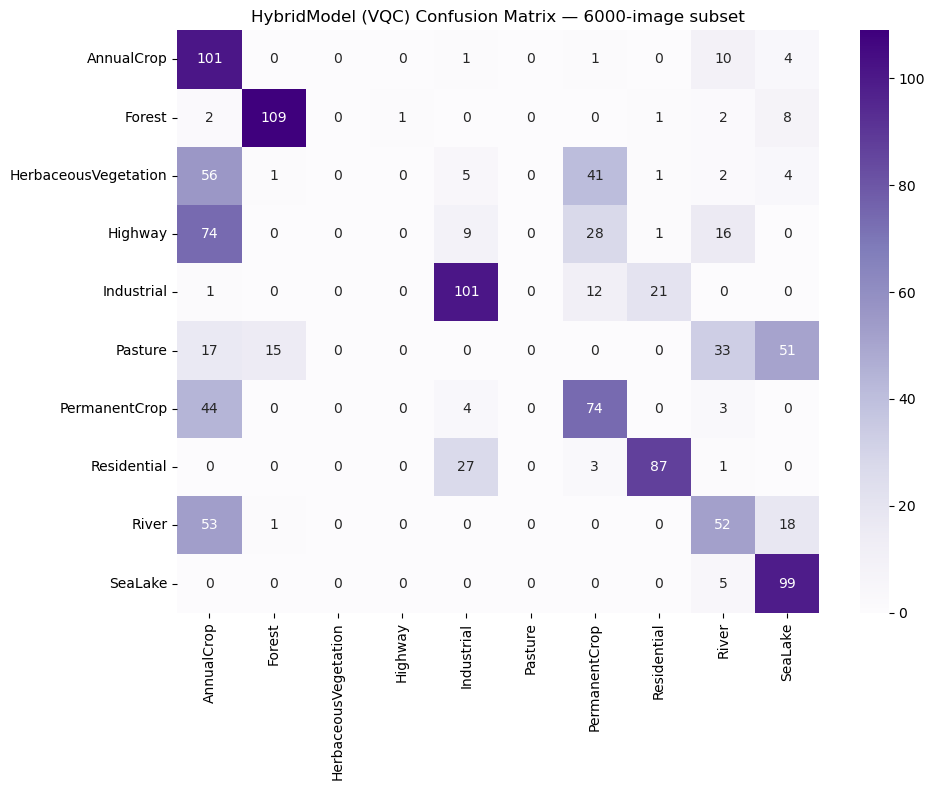

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes,
            yticklabels=classes, cmap='Purples')
plt.title('HybridModel (VQC) Confusion Matrix — 6000-image subset')
plt.tight_layout()
plt.savefig('../results/vqc_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
import time

model = HybridModel()
start = time.time()
history = train(model, train_loader, val_loader,
                epochs=15, lr=0.0005, device=device, save_name='hybrid_vqc_fulldataset')
print(f"\nTotal time: {(time.time()-start)/3600:.2f} hours")

Epoch 1/15 | Loss: 2.1076 | Val Acc: 0.3528
  ✓ Checkpoint saved (0.3528)
Epoch 2/15 | Loss: 1.9450 | Val Acc: 0.4560
  ✓ Checkpoint saved (0.4560)
Epoch 3/15 | Loss: 1.8263 | Val Acc: 0.4222
Epoch 4/15 | Loss: 1.7314 | Val Acc: 0.4694
  ✓ Checkpoint saved (0.4694)
Epoch 5/15 | Loss: 1.6458 | Val Acc: 0.4936
  ✓ Checkpoint saved (0.4936)
Epoch 6/15 | Loss: 1.5881 | Val Acc: 0.4400
Epoch 7/15 | Loss: 1.5288 | Val Acc: 0.5249
  ✓ Checkpoint saved (0.5249)
Epoch 8/15 | Loss: 1.4798 | Val Acc: 0.5489
  ✓ Checkpoint saved (0.5489)
Epoch 9/15 | Loss: 1.4428 | Val Acc: 0.5556
  ✓ Checkpoint saved (0.5556)
Epoch 10/15 | Loss: 1.4012 | Val Acc: 0.4943
Epoch 11/15 | Loss: 1.3658 | Val Acc: 0.5398
Epoch 12/15 | Loss: 1.3355 | Val Acc: 0.5790
  ✓ Checkpoint saved (0.5790)
Epoch 13/15 | Loss: 1.3133 | Val Acc: 0.5057
Epoch 14/15 | Loss: 1.2810 | Val Acc: 0.5711
Epoch 15/15 | Loss: 1.2594 | Val Acc: 0.5617

Total time: 1.76 hours


In [ ]:
model = HybridModel()
model.load_state_dict(torch.load('../checkpoints/hybrid_vqc_fulldataset_best.pth', map_location=device))
model.to(device)
model.eval()

classes = ['AnnualCrop','Forest','HerbaceousVegetation','Highway',
           'Industrial','Pasture','PermanentCrop','Residential','River','SeaLake']

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = model(images).argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

report = classification_report(all_labels, all_preds, target_names=classes, output_dict=True)
print(classification_report(all_labels, all_preds, target_names=classes))

with open('../results/vqc_fulldataset_results.json', 'w') as f:
    json.dump(report, f, indent=2)

NameError: name 'HybridModel' is not defined

In [15]:
model = HybridModel()
model.load_state_dict(torch.load('../checkpoints/hybrid_vqc_fulldataset_best.pth', map_location=device))
model.to(device)
model.eval()

classes = ['AnnualCrop','Forest','HerbaceousVegetation','Highway',
           'Industrial','Pasture','PermanentCrop','Residential','River','SeaLake']

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = model(images).argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

report = classification_report(all_labels, all_preds, target_names=classes, output_dict=True)
print(classification_report(all_labels, all_preds, target_names=classes))

with open('../results/vqc_fulldataset_results.json', 'w') as f:
    json.dump(report, f, indent=2)

C:\Users\RAGHAV\AppData\Local\Temp\ipykernel_15668\621425643.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('../checkpoints/hybrid_vqc_

                      precision    recall  f1-score   support

          AnnualCrop       0.52      0.94      0.67       445
              Forest       0.93      0.93      0.93       461
HerbaceousVegetation       0.43      0.77      0.55       470
             Highway       0.46      0.83      0.59       383
          Industrial       0.00      0.00      0.00       393
             Pasture       0.00      0.00      0.00       301
       PermanentCrop       0.00      0.00      0.00       350
         Residential       0.51      0.98      0.67       431
               River       0.50      0.00      0.01       368
             SeaLake       0.99      0.96      0.97       448

            accuracy                           0.59      4050
           macro avg       0.43      0.54      0.44      4050
        weighted avg       0.47      0.59      0.48      4050



c:\Users\RAGHAV\anaconda3\envs\lumoraq\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\RAGHAV\anaconda3\envs\lumoraq\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\RAGHAV\anaconda3\envs\lumoraq\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

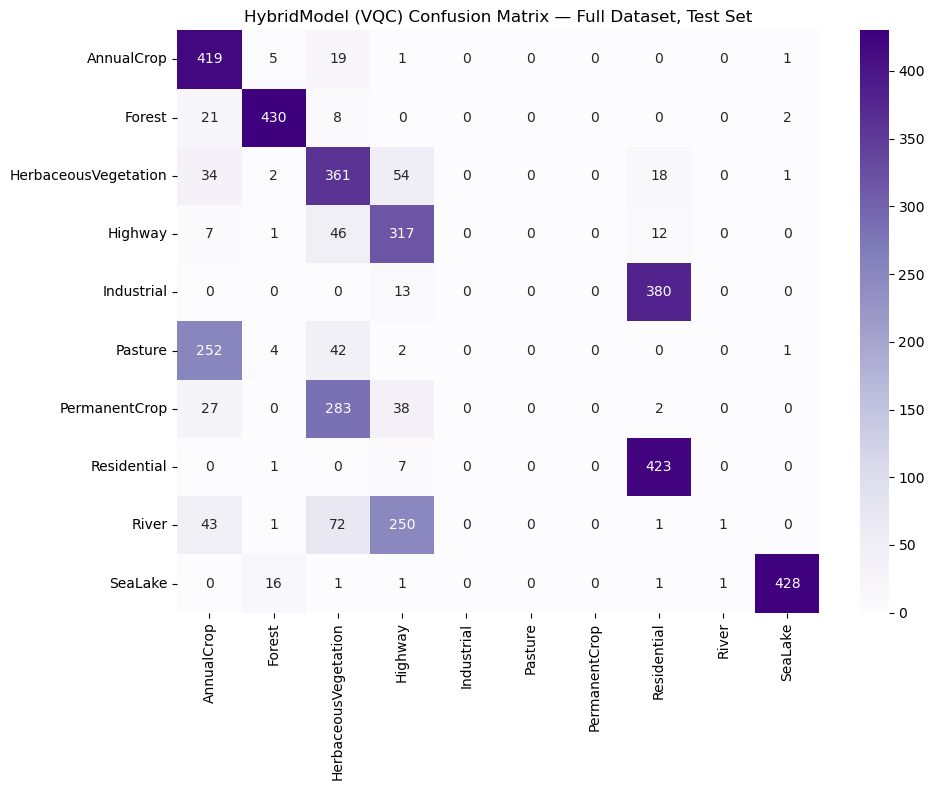

In [16]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes,
            yticklabels=classes, cmap='Purples')
plt.title('HybridModel (VQC) Confusion Matrix — Full Dataset, Test Set')
plt.tight_layout()
plt.savefig('../results/vqc_fulldataset_confusion_matrix.png', dpi=150)
plt.show()